# Logistic Regression: Rain Tomorrow Prediction
**Dataset:** Weather Observations — Albury, Australia  
**Target Variable:** `RainTomorrow` (Will it rain tomorrow? Yes/No)  
**Algorithm:** Logistic Regression

---

## 1. Introduction

Weather prediction is a classic binary classification problem. In this notebook, we use **Logistic Regression** to predict whether it will rain tomorrow in Albury, Australia, based on daily weather observations such as temperature, humidity, rainfall, and atmospheric pressure.

### Objectives
- Perform Exploratory Data Analysis (EDA) to understand the dataset
- Preprocess the data (handle missing values, encode categoricals, scale features)
- Train a Logistic Regression classifier
- Evaluate the model using Accuracy, Precision, Recall, F1 Score, and Confusion Matrix

### Dataset
The dataset contains daily weather observations from Albury, Australia. It includes numerical weather measurements and a binary target column `RainTomorrow`.

| Column | Description |
|--------|-------------|
| MinTemp | Minimum temperature (°C) |
| MaxTemp | Maximum temperature (°C) |
| Rainfall | Amount of rainfall (mm) |
| Humidity9am | Humidity at 9am (%) |
| Humidity3pm | Humidity at 3pm (%) |
| Pressure9am | Atmospheric pressure at 9am (hPa) |
| Pressure3pm | Atmospheric pressure at 3pm (hPa) |
| Temp9am | Temperature at 9am (°C) |
| Temp3pm | Temperature at 3pm (°C) |
| RainToday | Did it rain today? (Yes/No) |
| **RainTomorrow** | **Target: Will it rain tomorrow? (Yes/No)** |

---

## 2. Algorithm Explanation — Logistic Regression

**Logistic Regression** is a supervised machine learning algorithm used for **binary classification** tasks. Despite its name, it is a *classification* algorithm, not a regression one.

### How It Works

Logistic Regression models the **probability** that a given input belongs to a particular class (e.g., `RainTomorrow = Yes`).

It applies the **Sigmoid (Logistic) Function** to the linear combination of features:

$$P(y=1 \mid X) = \sigma(z) = \frac{1}{1 + e^{-z}}$$

where $z = w_0 + w_1x_1 + w_2x_2 + \cdots + w_nx_n$

The sigmoid function maps any real number to the range **(0, 1)**, which we interpret as a probability.

### Decision Boundary
- If $P(y=1) \geq 0.5$ → Predict **Rain Tomorrow (1)**
- If $P(y=1) < 0.5$ → Predict **No Rain Tomorrow (0)**

You can download the dataset from this link:
https://drive.google.com/file/d/1-JBsPuCEot815OTA63M25Q5GXSH2Dgb0/view?usp=sharing

#3. Import Libraries and Read the data

In [1]:
import warnings
# Suppress all warnings
warnings.filterwarnings('ignore')
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
df = pd.read_csv('weatherAlbury.csv')
print('Size of weather data frame is :',df.shape)
df.head()

Size of weather data frame is : (3011, 13)


,Date,Location,MinTemp,MaxTemp,Rainfall,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,01/12/2008,Albury,13.4,22.9,0.6,71.0,22.0,1007.7,1007.1,16.9,21.8,No,No
1,02/12/2008,Albury,7.4,25.1,0.0,44.0,25.0,1010.6,1007.8,17.2,24.3,No,No
2,03/12/2008,Albury,12.9,25.7,0.0,38.0,30.0,1007.6,1008.7,21.0,23.2,No,No
3,04/12/2008,Albury,9.2,28.0,0.0,45.0,16.0,1017.6,1012.8,18.1,26.5,No,No
4,05/12/2008,Albury,17.5,32.3,1.0,82.0,33.0,1010.8,1006.0,17.8,29.7,No,No


#4. EDA

In [2]:
df.duplicated().sum()

np.int64(0)

In [3]:
df.isnull().sum()

,0
Date,0
Location,0
MinTemp,6
MaxTemp,1
Rainfall,20
Humidity9am,4
Humidity3pm,4
Pressure9am,0
Pressure3pm,4
Temp9am,4


In [4]:
# Preprocess the data
df = df.dropna()
print("new shape:" ,df.shape)
#encoding
df['RainToday'].replace({'No': 0, 'Yes': 1},inplace = True)
df['RainTomorrow'].replace({'No': 0, 'Yes': 1},inplace = True)

new shape: (2981, 13)


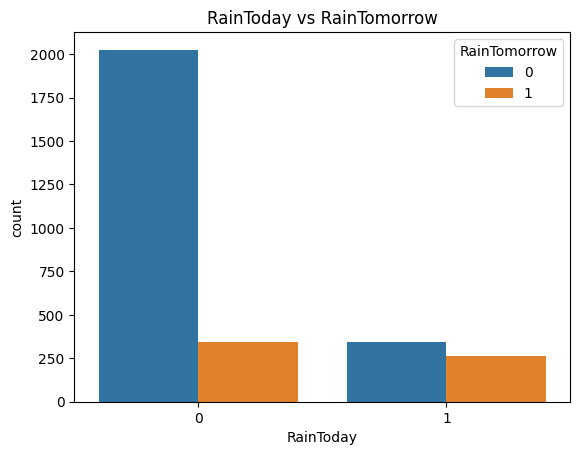

In [5]:
sns.countplot(x="RainToday", hue="RainTomorrow", data=df)
plt.title('RainToday vs RainTomorrow')
plt.show()

In [6]:
df["RainTomorrow"].value_counts(normalize=True)

,proportion
RainTomorrow,
0,0.795371
1,0.204629


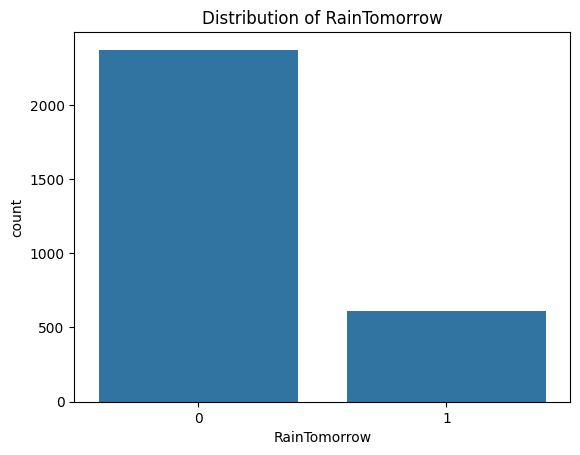

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="RainTomorrow", data=df)
plt.title("Distribution of RainTomorrow")
plt.show()

In [8]:
import numpy as np
corr = df.select_dtypes(include=np.number).corr()
target_corr = corr['RainTomorrow'].drop('RainTomorrow').sort_values(ascending=False)
print('\n Feature Correlations with RainTomorrow (sorted):')
print(target_corr.round(3).to_string())


 Feature Correlations with RainTomorrow (sorted):
Humidity3pm    0.468
RainToday      0.287
Humidity9am    0.216
Rainfall       0.206
MinTemp        0.075
Temp9am       -0.035
MaxTemp       -0.199
Temp3pm       -0.228
Pressure9am   -0.280
Pressure3pm   -0.304


#5. Model

In [9]:
# Implement Logistic Regression Model

X = df[["MinTemp", "MaxTemp", "Rainfall", "Humidity9am", "Humidity3pm", "Pressure9am",
        "Pressure3pm", "Temp9am", "Temp3pm", "RainToday"]]
y = df.RainTomorrow

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20, random_state=42)

In [10]:
def evaluate_model(model, X_test, y_test, model_name='Model'):
    """Fit is assumed done already. Prints metrics and plots confusion matrix."""
    y_pred = model.predict(X_test)

    print(f'===== {model_name} =====')
    print(f'Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
    print(f'F1 Score  : {f1_score(y_test, y_pred, average="macro"):.4f}')
    print(f'Precision : {precision_score(y_test, y_pred, average="macro"):.4f}')
    print(f'Recall    : {recall_score(y_test, y_pred, average="macro"):.4f}')
    print(f'\nClassification Report:\n{classification_report(y_test, y_pred)}')

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes']).plot()
    plt.title(model_name)
    plt.show()
    print('-' * 45)

===== Logistic Regression (default) =====
Accuracy  : 0.8693
F1 Score  : 0.7712
Precision : 0.8173
Recall    : 0.7436

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       477
           1       0.74      0.53      0.62       120

    accuracy                           0.87       597
   macro avg       0.82      0.74      0.77       597
weighted avg       0.86      0.87      0.86       597



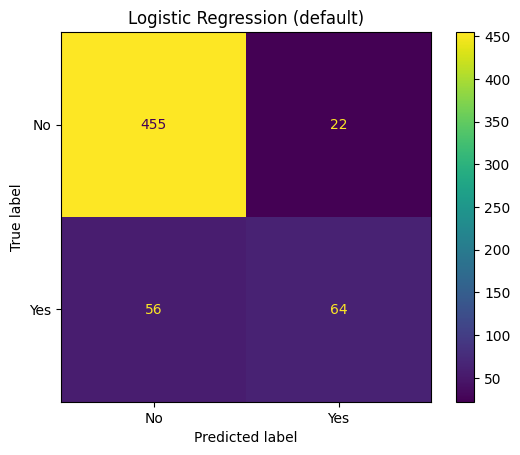

---------------------------------------------


In [11]:
# Default Logistic Regression (lbfgs solver)
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train, y_train)
evaluate_model(logreg, X_test, y_test, 'Logistic Regression (default)')

#6. Bouns

##6.1 Tune hyperparameters

assign solver = 'newton-cg', a optimization algorithm use L2 regularization

===== Logistic Regression (newton-cg) =====
Accuracy  : 0.8777
F1 Score  : 0.7914
Precision : 0.8267
Recall    : 0.7676

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.93       477
           1       0.75      0.58      0.66       120

    accuracy                           0.88       597
   macro avg       0.83      0.77      0.79       597
weighted avg       0.87      0.88      0.87       597



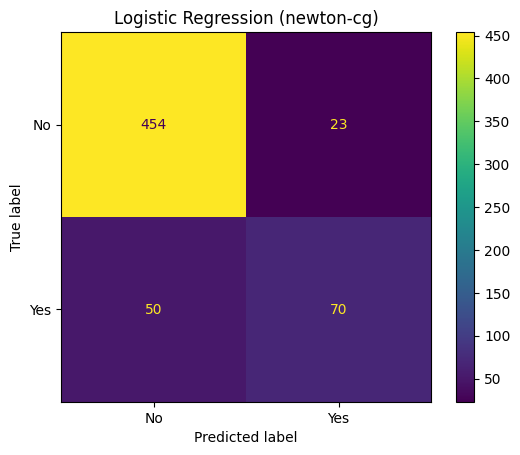

---------------------------------------------


In [12]:
logreg_newton = LogisticRegression(random_state=42, solver='newton-cg')
logreg_newton.fit(X_train, y_train)
evaluate_model(logreg_newton, X_test, y_test, 'Logistic Regression (newton-cg)')

##6.2. Use Another Algorithm

===== SVC =====
Accuracy  : 0.7990
F1 Score  : 0.4441
Precision : 0.3995
Recall    : 0.5000

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       477
           1       0.00      0.00      0.00       120

    accuracy                           0.80       597
   macro avg       0.40      0.50      0.44       597
weighted avg       0.64      0.80      0.71       597



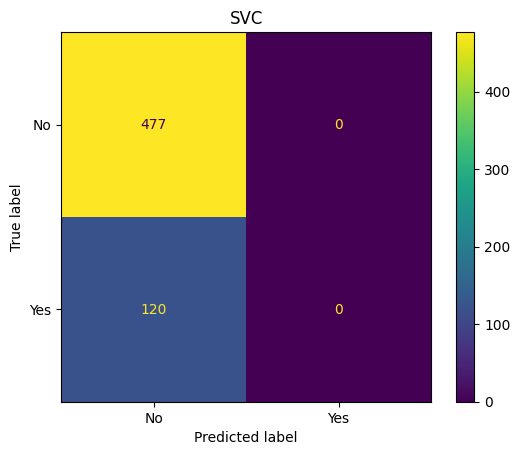

---------------------------------------------
===== KNN =====
Accuracy  : 0.8660
F1 Score  : 0.7578
Precision : 0.8194
Recall    : 0.7259

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       477
           1       0.76      0.49      0.60       120

    accuracy                           0.87       597
   macro avg       0.82      0.73      0.76       597
weighted avg       0.86      0.87      0.85       597



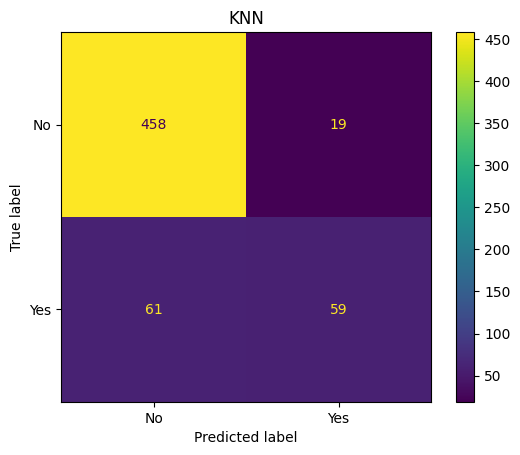

---------------------------------------------
===== Random Forest =====
Accuracy  : 0.8760
F1 Score  : 0.7862
Precision : 0.8265
Recall    : 0.7603

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       477
           1       0.76      0.57      0.65       120

    accuracy                           0.88       597
   macro avg       0.83      0.76      0.79       597
weighted avg       0.87      0.88      0.87       597



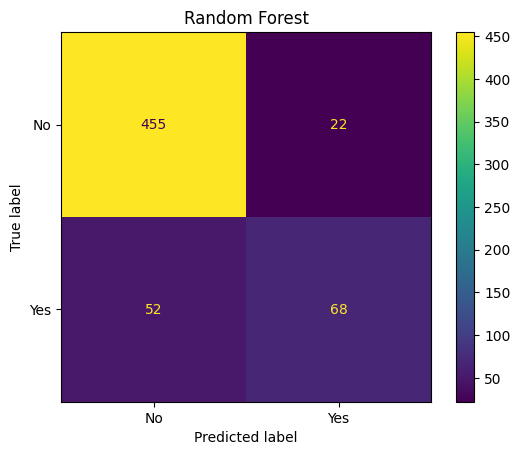

---------------------------------------------


In [13]:
models = {
    'SVC'          : SVC(random_state=42),
    'KNN'          : KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    evaluate_model(model, X_test, y_test, name)

#7. Conclusion
After training and evaluating five models on the Albury weather dataset, Logistic Regression with the newton-cg solver achieved the best overall results